In [8]:
import cv2
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

img=cv2.imread("/content/drive/MyDrive/opencv/umbrella.jpg")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


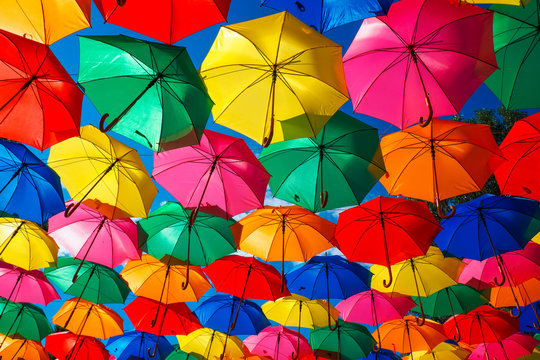

In [9]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

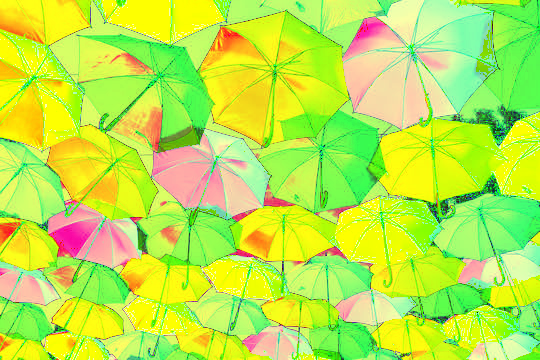

In [10]:
hsv_img=cv2.cvtColor(img , cv2.COLOR_BGR2HSV)
cv2_imshow(hsv_img)

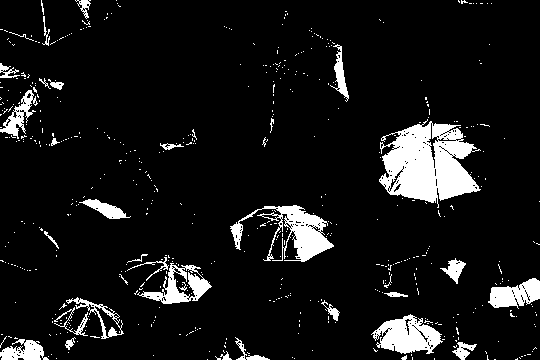

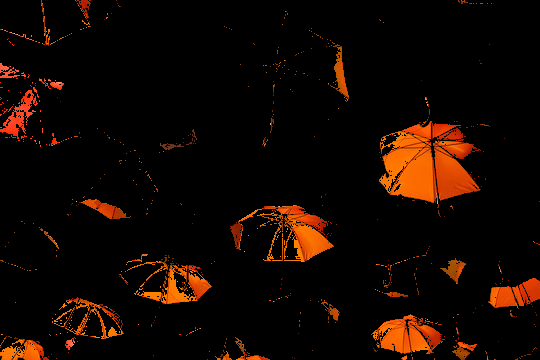

In [11]:
#color thresholding 
lower_orange = np.array([5, 100, 100])
upper_orange = np.array([15, 255, 255])

mask = cv2.inRange(hsv_img, lower_orange, upper_orange)
result = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(mask)
cv2_imshow(result)

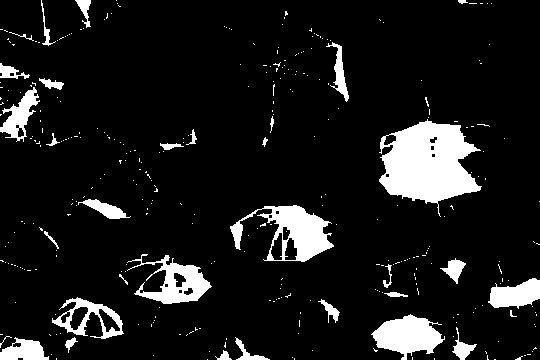

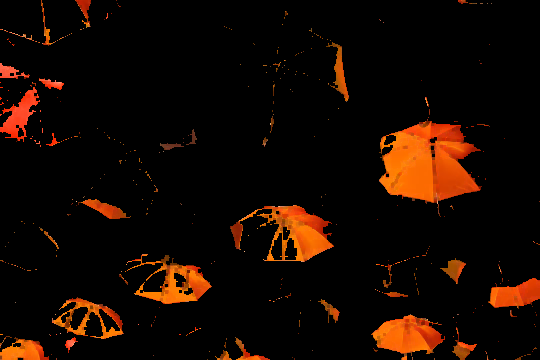

In [12]:
kernel=np.ones((3, 3), np.uint8)
img2 = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
img2= cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
img3 = cv2.morphologyEx(result, cv2.MORPH_OPEN, kernel)
img3= cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)
cv2_imshow(img2)
cv2_imshow(img3)



In [15]:
Contours1, hierarchy1 = cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
Contours2, hierarchy2 = cv2.findContours(img2, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
Contours3, hierarchy3 = cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)



In [21]:


for contour in Contours1:
    area = cv2.contourArea(contour)

    if area < 100:
        continue

    perimeter = cv2.arcLength(contour, True)
    epsilon = 0.02 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    vertices = len(approx)

    if vertices == 3:
        shape = "Triangle"

    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)
        shape = "Square" if 0.95 <= aspect_ratio <= 1.05 else "Rectangle"

    else:
        circularity = 4 * np.pi * (area / (perimeter ** 2))
        shape = "Circle" if circularity > 0.8 else "Unknown"

    # DRAW CONTOUR
    cv2.drawContours(image_contours, [contour], -1, (0, 255, 0), 2)

    # Optional: put shape name
    x, y, w, h = cv2.boundingRect(contour)
    cv2.putText(image_contours, shape, (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

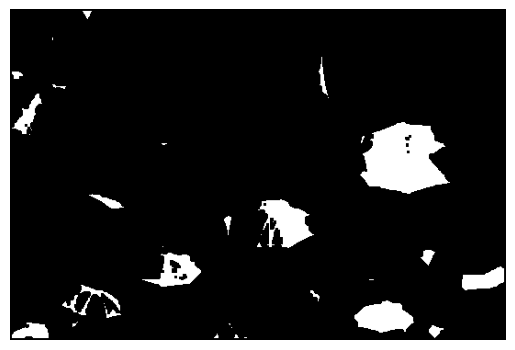

In [22]:
import matplotlib.pyplot as plt
image_contours = img2.copy()

cv2.drawContours(image_contours, Contours1, -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(image_contours, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()